# Autoestudio 1 - Estrategia incremental y analisis asintotico

Al finalizar este autoestudio debe adquirir conocimiento para:
1. Realizar la especificación de un problema
2. Diseñar la solución de problemas usando invariantes
3. Comprender algunas funciones útiles en el cálculo de complejidad














In [ ]:
#@title Datos
Nombre = "" # @param {"type":"string"}
Carnet = 0 # @param {"type":"integer"}


----

# Especificación

Un algoritmo es un procedimiento computacional, que transforma una **entrada** en una **salida**, para lograr realizar una tarea especifica. Para que este sea relevante, debe resolver un problema general y _bien especificado_.


La especificacion de un problema algorítmico consiste en describir el conjunto completo de **entradas** donde se debe trabajar (posibles *instancias*), asi mismo como las **salidas** esperadas despues de correr sobre cada una de las **entradas** concretas. Es necesario que quede clara la relación deseada entre cada **entrada** y su correspondiente **salida**.

El conocido problema de *ordenamiento* puede especificarse de la siguiente forma:


> **Problema**: Ordenamiento.
>
> **Entrada**: Una secuencia de $n$ valores $\langle a_1, \ldots, a_n \rangle$.
>
> **Salida**: Una permutacion (reordenamiento) de la secuencia de entrada $\langle a_1^{\prime}, \ldots, a_n^{\prime} \rangle$ tal que $a_1^{\prime} \leq a_2^{\prime} \leq \cdots \leq a_n^{\prime}$.

----

Basado parcialmente de _Algorithm Design Manual_ de Steven Skiena.





##La entrada
Algo a notar de esta especificacion es que la entrada esta siendo explicita en las posibles instancias que se pueden recibir, en particular es una secuencia de elementos, donde vamos a recibir un total de $n$ de ellos. Por contexto podriamos inferir que es $n>0$, o bien $n\in\mathbb{N}$.

Adicionalmente no se esta acotando los posibles valores que pueden estar dentro de nuestra secuencia, no se esta especificando que son numeros ni nada en particular, lo unico que podemos inferir, por ser un problema de ordenamiento, es que que los elementos son comparables, y que existe una unica forma de organizarlos. En la **salida** se indica que deben poder compararse con el operador de menor o igual ($\leq$).

Bajo esta definicion podemos ser tan flexibles como decir que los valores de entrada podrian ser secuencias de texto, y aun asi se estaria cumpliendo con la especificacion.
```python
["Alejandro", "Santiago", "Laura"]
```
¿Como estableceriamos que significa $\leq$? Depende del caso. Para el caso concreto de secuencias de texto, el metodo usual de comparacion es por medio de algo llamado *orden lexicografico*.



## La salida
La salida también es una secuencia que cumple dos condiciones especiales. La primera, es que la salida está ordenada y la segunda, es que es una permutación de la entrada. En la segunda condición es en la que establecemos la relación entre la entrada y la salida.

Para la secuencia de cadenas de texto anterior, la única secuencia que cumple la especificación es la siguiente:
```python
["Alejandro", "Laura", "Santiago"]
```

Cabe recalcar que la salida debe tener una relacion directa con la entrada, y que en este caso, la secuencia de salida contiene exactamente los mismos elementos que se tienen de la entrada (ambos tienen $n$ elementos) y que estan organizados cumpliendo la condicion requerida de la salida.

##Entrada (precondición)  + Salida (poscondición)

Finalmente, como puede observar, nuestra especificacion puede ser tan laxa o tan estricta como queramos, usualmente nos interesa tener especificaciones estrictas, ya que acotamos nuestro problema a lo minimo necesario.

##$\color{blue}{Ejercicios}$

1. **Investigue** que es un orden lexicografico.

Un orden lexicografico es ...

2. **Proponga** dos entradas válidas y dos entradas inválidas para el problema de ordenamiento. Indique por que son invalidas.

3. **Proponga** dos problemas y expecifiquelos. No olvide indicar las condiciones que debe cumplir la entrada y la salida.

**Problema:**

**Entrada:**

**Salida:**

**Problema:**

**Entrada:**

**Salida:**

# Diseño. Estrategia incremental. Invariante.

En algoritmos, es importante diseñar algoritmos que aseguren *correctitud*, que en esencia es poder determinar que mi algoritmo, dado una entrada, de una salida con la solucion correcta de esa entrada.

Una forma de diseñar algorimos correctos, usando la estrategia incremental, es por medio de *invariantes*, que como el nombre indica, es una propiedad que se mantiene constante durante la ejecucion de nuestro algoritmo.

Nos concentraremos sobre *invariantes de ciclo*, los cuales estaran enfocados a los ciclos dentro de nuestro algoritmo.

De manera similar a la inducción, que consiste en establecer un caso *base*, y un caso *inductivo*, en un diseño con invariantes debemos asegurar tres (3) propiedades:

1. **Iniciacion**: El invariante es verdadero antes de iniciar la primera iteracion.
2. **Mantenibilidad**: Si el invariante es cierto antes de una iteracion del ciclo, se mantiene cierto después dicha iteración.
3. **Terminacion**: Al terminar el ciclo, el invariante debe ayudar a asegurar que se ha alcanzado el objetivo del algoritmo

## Ejemplo: Mínimo

###Especificación

Considere la siguiente especificación:

> **Problema:** Mínimo
>
> **Entrada:** Una secuencia de $n$ numeros enteros $A = \langle A[0], \ldots, A[n-1] \rangle$
>
> **Salida:** Un numero entero $r\in A$, donde $r$ es el elemento de menor valor dentro de $A$, es decir $r = \min(A[0], \ldots, A[n-1])$

###Diseño (Invariante)
Para que nosotros podamos especificar una invariante basada en el problema, podemos partir de lo que se quiere como resultado final que es $r = \min(A[0], \ldots, A[n-1])$ y luego proceder a debilitar la proposicion.

Podemos sintetizar la invariante empezando por:
$$
r_i = \min(A[0], \ldots, A[i-1])
$$
donde $r$ es el minimo desde el elemento $A[0]$ hasta $A[i-1]$, donde $0 < i \leq n$.

Asi nos queda la invariante:
$$
Inv: 0 < i \leq n \ \land\ r_i = \min(A[0], \ldots, A[i-1])
$$

Para que nosotros podamos usar este invariante para calcular el valor minimo de una secuencia debemos asegurar que se cumpla cada una de las propiedades mencionadas anteriormente:

**Iniciacion:** La invariante es cierta cuando $i = 1$, esto debido a que $r_1 = \min(A[0]) = A[0]$, siendo el minimo de un solo elemento esto es trivialmente correcto.



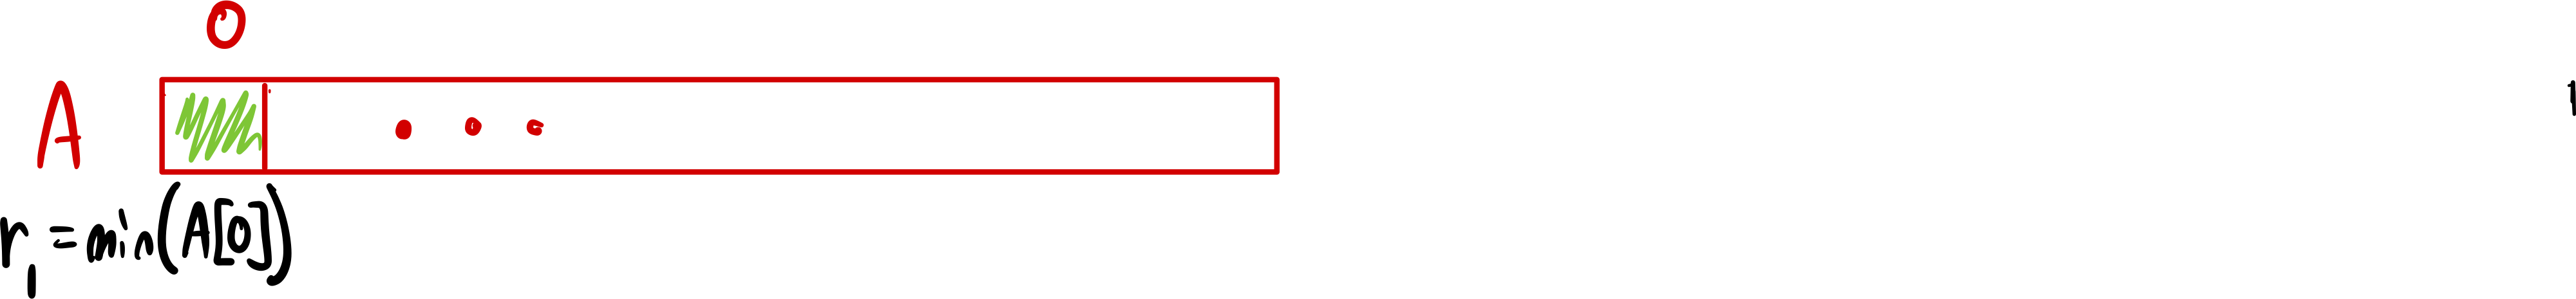

**Mantenibilidad:** Ahora asumiendo que $r_i = \min(A[0], \ldots, A[i-1])$ es correcto, queremos asegurar que sigue siendo correcto cuando $r_{i+1} = \min(A[0], \ldots, A[i])$.

Para esto basta con garantizar que
$$
\begin{align*}
    r_{i+1} =& \min(A[0], \ldots, A[i]) \\
            =& \min(A[0], \ldots, A[i-1], A[i]) \\
            =& \min(\min(A[0], \ldots, A[i-1]), A[i]) \\
            =& \min(r_i, A[i]) \\
\end{align*}
$$

Lo cual muestra que $r_{i+1}$ es el minimo entre $r_i$ y el nuevo elemento $A[i]$.



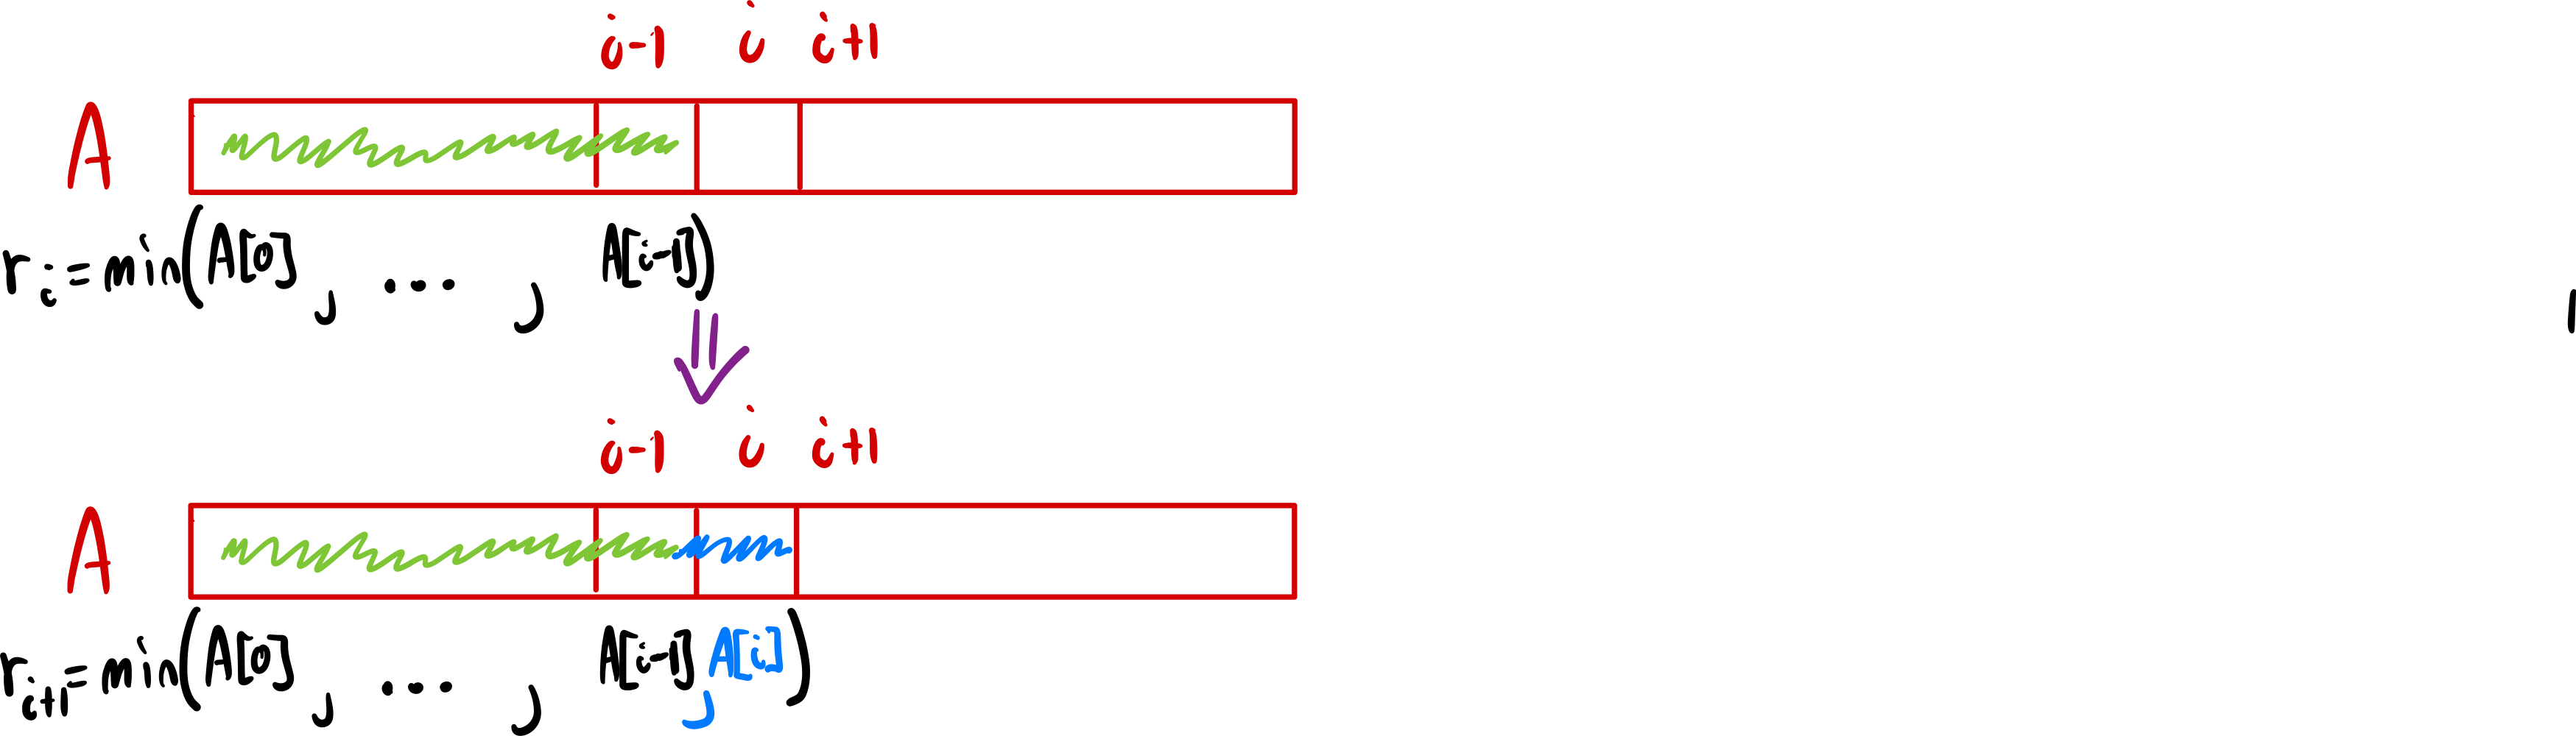

**Terminacion:** Ahora, sabiendo que lo anterior es correcto, podemos asumir que el invariante $Inv$ es correcto para cualquier valor valido de $i$, lo cual incluye a $i=n$. Luego tenemos:
$$
r_n = \min(A[0], \ldots, A[n-1])
$$
la cual es la condicion que queriamos mostrar en la salida de la especificacion del problema.

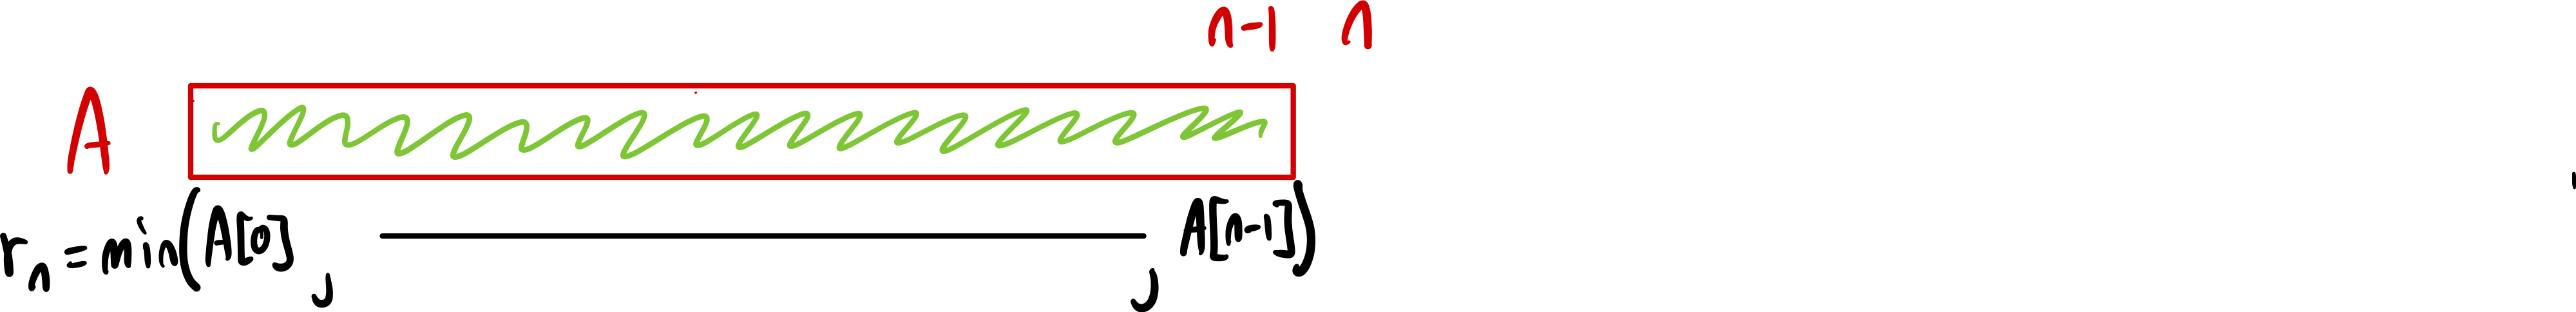

### Código
Basado en el invariante $Inv$ podemos ahora escribir código que resuelve el problema dado en la especificacion.

Considere el siguiente fragmento de codigo:

In [ ]:
def omin(A: list[int]) -> int:
  n = len(A)
  r, i = A[0], 1
  while i != n:
    r, i = min(r, A[i]), i+1
  return r

Se puede apreciar que las condiciones iniciales para las variables $i$ y $r$ son las mismas mostradas en la fase de *iniciacion*, luego de esto calculamos el nuevo valor de $r$ y cambiamos el valor de $i$ aumentando su valor hasta que $i = n$.

Cuando esto se da, ya que sabemos que el invariante se cumple, tendremos como resultado que el valor de $r$ contendra el valor minimo de la secuencia $A$ cuando $i$ llegue a ser $n$.

Podemos tambien comprobar con algun caso trivial.

In [ ]:
print(omin([-1, 0, 3, 6, 2]))
print(omin([0, 9, 2, 1]))
print(omin([2]))

-1
0
2


##$\color{blue}{Ejercicios}$



Considere la siguiente especificacion:

> **Problema:** Suma
>
> **Entrada:** Una secuencia de $n$ numeros enteros $A = \langle A[0], \ldots, A[n-1] \rangle$
>
> **Salida:** Un valor entero $r$ tal que es la suma de todos los elementos de $A$, es decir $r = \sum_{i = 0}^{n-1} A[i]$.

1. **Establezcla** un invariante y use sus propiedades de iniciacion, estabilidad y terminacion para mostrar que el algoritmo retorna la suma de los $n$ numeros de $A$. Incluya un gráfico que lo ilustre.

**Nota de ayuda:** Un caso valido de entrada para esta especificacion es cuando $n=0$, es decir que $A = [\ ]$. Para este caso queremos que $r=0$.

**Invariante:**

**Inicialización:**

**Estabilidad:**

**Terminación:**

**Grafico:**

# Analisis de complejidad

Aparte de la correctitud de nuestro algoritmo, tambien es importante conocer como este se va a comportar con los recursos que ponemos a su disposicion.

Estos recursos pueden ser _tiempo_ o _espacio_ en el contexto de algoritmos de computadores.

En esta sección, solo nos concentramos en hacer un analisis de tiempo de ejecucion, eso es ¿Cuanto tiempo se demora nuestro algoritmo en ejecutar? Esto sin tener en cuenta una unidad fisica concreta, ya que esta estaria dada por alguna constante $c$ que usualmente estaria en el orden de nanosegundos para un computador moderno.

Dentro de este campo, usualmente nos interesa analizar el **mejor**, el **peor**, y el caso **promedio** del uso de nuestros recursos.

Usualmente cuando nos referimos a esto se les llama _complejidad_, si hablamos de tiempo de ejecucion, lo podriamos llamar _complejidad temporal_. Asi mismo para el espacio seria _complejidad espacial_.

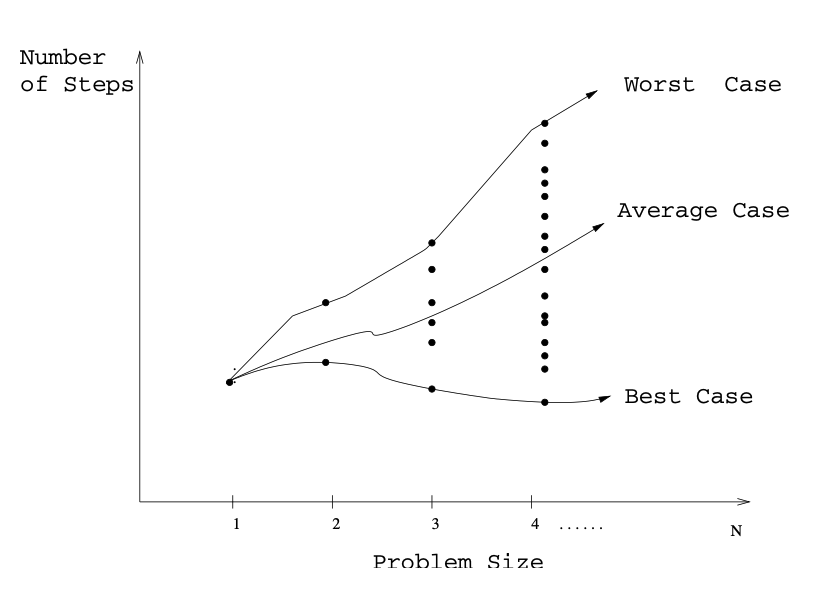

Usualmente nos iteresa el peor caso, esto porque con esto podemos saber con que tanto tiempo/espacio debemos contar.

Como vimos en clase, nuestros analisis pueden volverse en formular complejas de multiples parametros, y que mas aun, varian segun la forma de entrada que estemos analizando.

**Nota**: Asumase que para cualquiera de las funciones de complejidad temporal o complejidad espacial. El dominio y el rango de las funciones que expresemos siempre estaran dado por los numeros naturales $\mathbb{N}$. Por ejemplo, no tiene sentido que ordenar una secuencia tome $5.5$ pasos.
$$
f(n):  \mathbb{N} \rightarrow \mathbb{N}
$$
El dominio es el tamaño de la entrada que se calcula con base al conjunto de parámetros posibles para nuestro algoritmo.


## Notacion asintotica

Nuestros analisis de complejidad para cualquier algoritmo dado son funciones numericas sobre un tamaño de entrada, sin embargo es muy dificil trabajar con estas funciones por si solas, dado que:

- **Son inexactas**: Debido a que las particularidades de cada entrada en nuestro algoritmo introduce inexactitudes en donde este se demora ligeramente mas para unas instancias, y se demorarian ligeramente menos para otras.

- **Requieren mucho detalle para especificarlos de manera exacta**: Establecer una formula exacta implica conocer cada uno de los detalles insignificantes de nuestro algoritmo, tal que en la practica se vuelve tedioso e irrelevante.

Adicionalmente, rara vez nos interesa guardar todos los detalles del tiempo de ejecucion de nuestro algoritmo, por lo que solo nos interesa una aproximado cercano al valor real.

Tome como ejemplo la formula:
$$
T(n) = 12n^2 + 43n + 8\log_{2} n + 136
$$

A pesar de que nos ofrece mayores detalles del tiempo de ejecucion de nuestro algoritmo, para efectos practicos es más útil identificar que el tiempo "crece cuadraticamente con $n$".

La notación asintotica ignora diferencias de las constantes multiplicativas en nuestra formula en forma de polinomio.

Por esta razon, la notacion asintotica de $O$ (Big Oh), $\Omega$ (Omega) y $\Theta$ (Theta) nos proveen una vista de las funciones para poder comparar entre algoritmos de manera mas sencilla.

Si nos vamos a las definiciones formales de cada una las tendriamos definidas asi:
- $O(g(n)) = \{f(n) : \text{existen constantes positivas } c>0\text{ y } n_0\geq 0 \text{ tal que } 0 \leq f(n) \leq cg(n)\} $
- $\Omega(g(n)) = \{f(n) : \text{existen constantes positivas } c>0\text{ y } n_0\geq 0 \text{ tal que } 0 \leq cg(n) \leq f(n)\} $
- $\Theta(g(n)) = \{f(n) : \text{existen constantes positivas } c_1>0 \text{, } c_2 > 0 \text{ y } n_0\geq 0 \text{ tal que } 0 \leq c_{1}g(n) \leq f(n) \leq c_{2}g(n) \} $

La correspondencia de cada una de las notaciones con los casos que queremos ver en los algoritmos, es:
- Peor caso (upper bound): $O$
- Mejor caso (lower bound): $\Omega$
- Caso promedio: $\Theta$

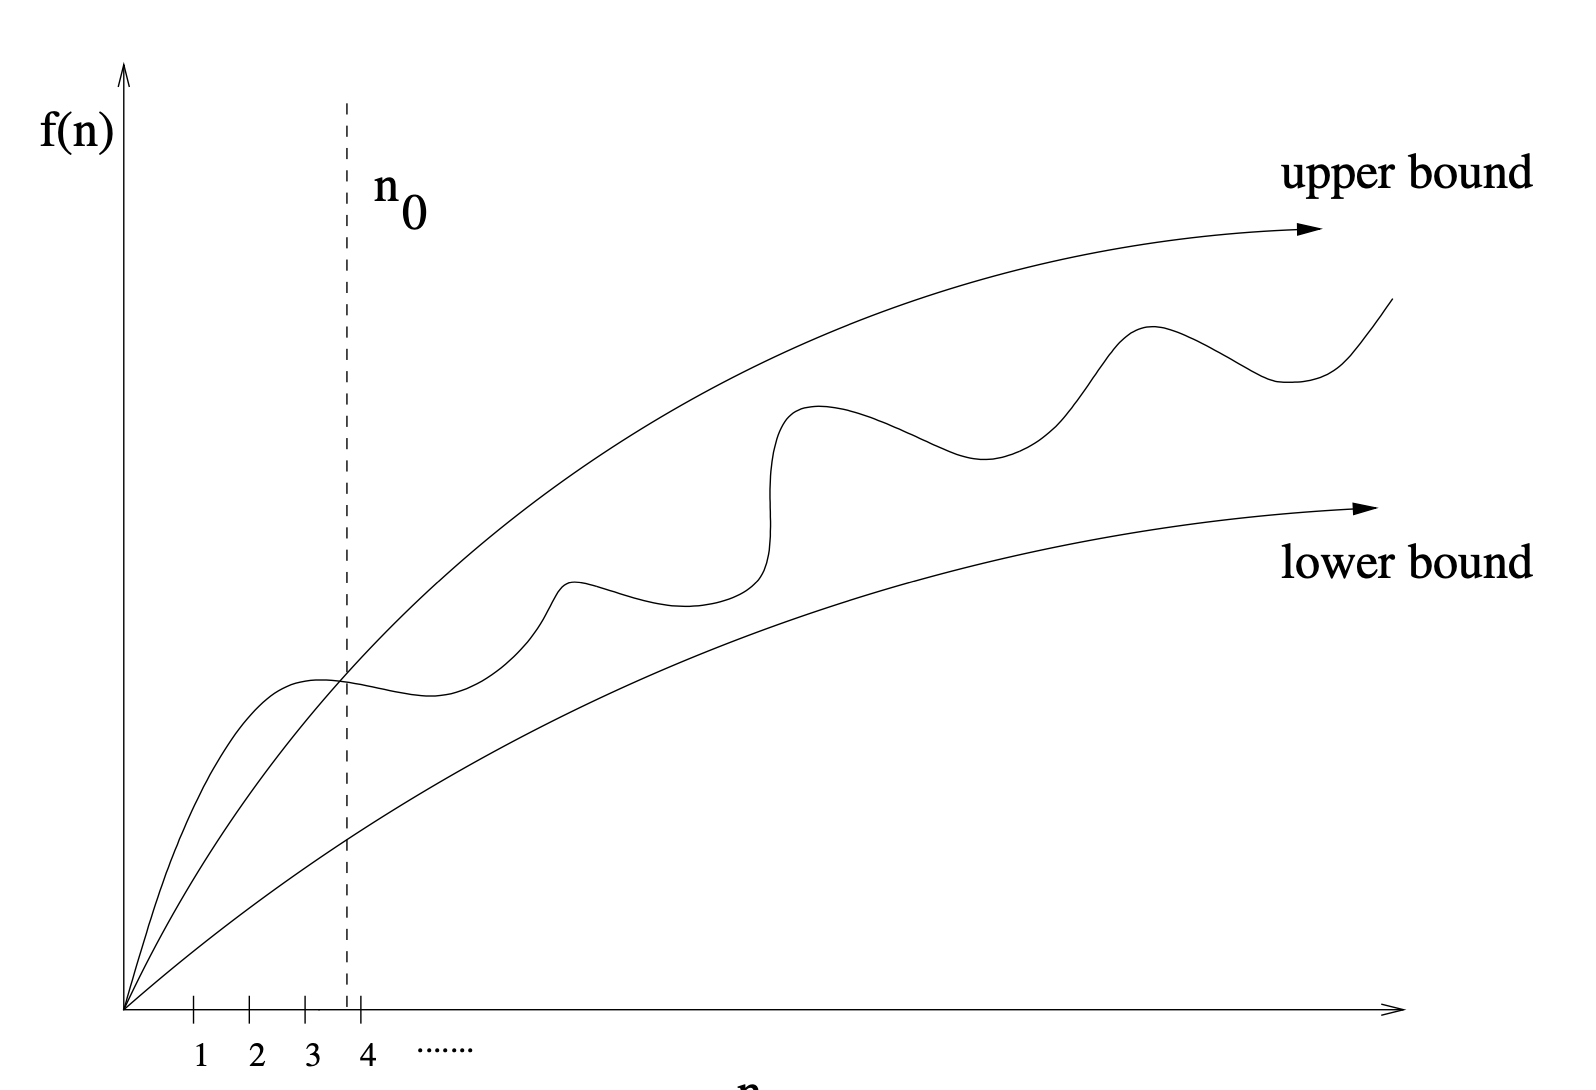

**¿Porque?**

Para el peor caso queremos definir un limite/cota _superior_, de la cual nuestra funcion de tiempo no va a superar. Este caso es usualmente por el que mas estaremos interesados al momento de tomar decisiones en algoritmos.

Para el mejor caso, de manera similar establecemos un limite/cota _inferior_, de la cual nuestra funcion de tiempo no puede mejorar.

Para el caso promedio, se determina el comportamiento esperado de un algoritmo sobre una distribución de entradas.

----

Para entender mejor el hecho de que las notaciones nos estan hablando de conjuntos, queremos poder determinar si una funcion pertenece a alguno de estos conjuntos.

> **Nota:** la notacion $f(n) = O(g(n))$ es un abuso de notacion que realmente esta expresando que $f(n)$ es una funcion que pertenece al conjunto $O(g(n))$, es decir $f(n) \in O(g(n))$.

Tomemos de ejemplo los siguientes casos:
- ¿$3n^2 - 100n+ 6 = O(n^2)$? Si escogemos a $c = 3$ y tenemos $3n^2 > 3n^2
- 100n + 6$, por lo que la respuesta es **Si**.
- ¿$3n^2 - 100n + 6 = O(n^3)$?, si escogemos a $c = 1$ y tenemos $n^3 > 3n^2 - 100n + 6$ cuando $n > 3$, por lo que la respuesta es **Si**.
- ¿$3n^2 - 100n + 6 = O(n)$?, no importa la constante $c$ que escoja, $cn < 3n^2$ cuando $n > c$, por lo que la respuesta es **No**, sucede que $3n^2 - 100n + 6 \neq O(n)$.

## Comparación
Ahora, queremos tambien poder comparar entre diferentes algoritmos, suponiendo que ya determinamos las formulas asintoticas de cada uno, si queremos compararlos, lo que necesitamos observar es como se comportan con valores suficientemente grandes para $n$.

> Nota: las graficas esta en escala logaritmica.

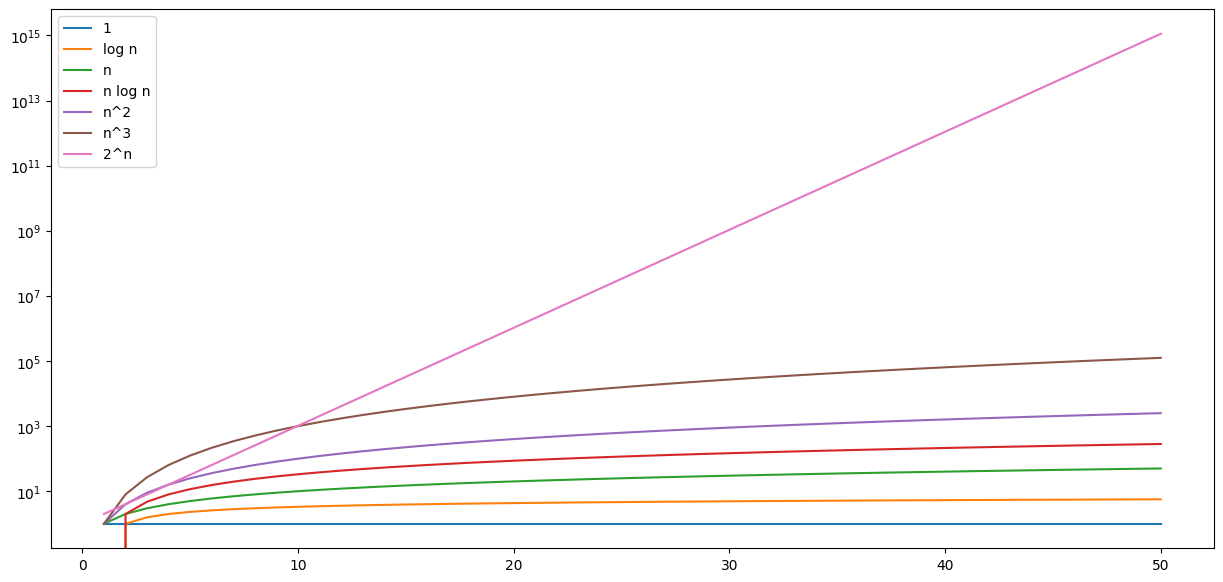

In [ ]:
import matplotlib.pyplot as plt
from math import log2

# Funciones
funcs = [
    (lambda n: 1, "1"),
    (lambda n: log2(n), "log n"),
    (lambda n: n, "n"),
    (lambda n: n*log2(n), "n log n"),
    (lambda n: n**2, "n^2"),
    (lambda n: n**3, "n^3"),
    (lambda n: 2**n, "2^n"),
]

# Graficas
plt.figure(figsize=(15, 7))
x = [n for n in range(1, 51)]
for fun, label in funcs:
  y = [fun(n) for n in x]
  plt.plot(x, y, label=label)

plt.yscale('log')
plt.legend()
plt.show()

## $\color{blue}{Ejercicios}$
Responda las siguientes preguntas:

- ¿$3n^2 - 100n+ 6 = \Omega(n^2)$?
- ¿$3n^2 - 100n + 6 = \Omega(n^3)$?
- ¿$3n^2 - 100n + 6 = \Omega(n)$?


- ¿$3n^2 - 100n+ 6 = \Theta(n^2)$?
- ¿$3n^2 - 100n + 6 = \Theta(n^3)$?
- ¿$3n^2 - 100n + 6 = \Theta(n)$?

**Bonos:**
- ¿Es $2^{n+1} = O(2^{n})$? Demuestre o refute
- ¿Es $2^{2n} = O(2^{n})$? Demuestre o refute
- ¿Es $2^{n+1} = \Omega(2^{n})$? Demuestre o refute
- ¿Es $2^{n+1} = \Theta(2^{n})$? Demuestre o refute
- ¿Es $(x+y)^2 = O(x^2+y^2)$? Demuestre o refute

----

##BONO


### UVa 136 - Ugly Numbers

**Link**: https://vjudge.net/problem/UVA-136

Los numeros "feos" son numeros cuyos unicos factores primos son $2$, $3$, o $5$. La secuencia de numeros

\begin{equation*}
1, 2, 3, 4, 5, 6, 8, 9, 10, 12, 15, \ldots
\end{equation*}

son los primeros $11$ numeros "feos". Por convencion, el numero $1$ esta incluido. Escriba un programa que encuentre e imprima el numero "feo" en la posicion $1500$.

### Entrada
No existe entrada para este programa

### Salida
La salida consiste de una sola salida como se comprende abajo, con '\<number\>' reemplazado por el numero computado.

### Salida de ejemplo
```
The 1500'th ugly number is <number>.
```

#### ¿Como resolver este ejercicio?
Para resolver este ejercicio primero debemos de reconocer que existe un numero limitado de numeros que podemos representar en un computador, dicho de otra manera, la capacidad de almacenamiento de un entero por lo general es de 64 bits, significa que podemos representar desde el numero $0$ hasta $2^{64}-1$ (asumiendo que el numero no tenga signo +/-).

Para esto tambien tengamos en cuenta que cualquier numero 'feo' que estemos generando de esta secuencia tendran la siguiente forma
$$
2^{i} \times 3^{j} \times 5^{k}
$$
Donde $i$, $j$, y $k$ van desde $0$ hasta un numero maximo.

¿Cual deberia ser este numero maximo para cada uno? Denotemoslo como una constante $p$.

Necesitamos al menos 1500 numeros de esta secuencia para poder calcular el numero requerido.

Lo que podemos hacer es generar todos los numeros por medio de tres ciclos anidados que varien las variables $i$, $j$ y $k$ para generar cada uno de los numeros.

Para cada numero generado debemos insertarlo dentro de un arreglo, luego de ser generados todos los numeros. Para saber directamente cual es el numero 1500 de esta secuencia debemos organizar este arreglo, obtener el valor en esta posicion e imprimirlo como indica el ejercicio.

Para este ejercicio vamos a responder las siguientes preguntas

 - ¿Cual es un valor minimo de $p$ que nos permita obtener ese numero de la secuencia correctamente en un tiempo razonable (pasa en el juez virtual)?
   - Experimente con valores de $p$ muy pequeños y muy grandes (e.g. $p=1.000.000$) ¿Que sucede con el algoritmo? ¿Intente en la arena y especifique cual es el veredicto de la arena?

- A pesar que no tenemos una entrada de datos en nuestro algoritmo, si tenemos un costo de tiempo ¿con base a que variable depende el tiempo de ejecucion de nuestro algorimo?

- En el codigo estamos haciendo uso de la funcion `sort` de Python. Investigue cual es la funcion de tiempo de ejecucion de este algoritmo, tanto para el mejor caso $\Omega(g(n))$ como para el peor caso $O(g(n))$. ¿Podemos decir que $\Theta(g(n))$ esta definido para este algoritmo?

 Puede usar el la arena del autoestudio o el link del problema para comprobar su respuesta.

In [ ]:
def solve() -> int:
  p = 1 # Modifique solo este valor
  values = []
  for i in range(p):
    for j in range(p):
      for k in range(p):
          v = (2 ** i) * (3 ** j) * (5 ** k)
          values.append(v)

  values.sort()
  if len(values) < 1500:
    raise ValueError("No hay suficientes valores calculados, intente con un valor mas grande para 'p'")

  return values[1499]

def main():
  ugly1500 = solve()
  print(f"The 1500'th ugly number is {ugly1500}.")

main()

ValueError: No hay suficientes valores calculados, intente con un valor mas grande para 'p'